In [204]:
"""
Automatically reloads libraries and utilities every time a cell is run
"""
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [205]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.PSF_helpers import *
from utils.Plot_helpers import *
from utils.Zernike_helpers import *
from utils.Booth_helpers import *

import numpy as np
import matplotlib.pyplot as plt

In [206]:
#minor style things to make the figures look nice
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

In [207]:
N_order = 3                # 3 for 3P, 2 for 2P
lambd = 1.3e-3             # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05             # Numerical aperture
f = 7.2                    # Focal length of objective (Olympus) [mm]
grid_size = 128            # BFP resolution
L_bfp = 15.12              # BFP diameter [mm]
mag = 4                    # Magnification rate from input to objective
w_0 = 3.5                  # mm
num_apt = 1.05

In [208]:
r_pupil = f * num_apt
r_bfp = L_bfp / 2
na_eff = num_apt
#effective NA can be limited by the size of the back focal plane
if r_bfp < r_pupil:
    na_eff = r_bfp / f
alpha = np.arcsin(na_eff / n)

theta_grid_size = 64
R_BFP = r_bfp

microscope = Microscope(N_order, lambd, n, num_apt, f, mag, w_0, L_bfp, theta_grid_size)

In [234]:
L_ffp = 0.012
grid_ffp = 256
grid = Centered_Square_Grid(L_ffp, grid_ffp, 0)
n_beads = 1
bead_img = Bead_Image(grid, np.random.uniform(-0.002, 0.002, n_beads), np.random.uniform(-0.002, 0.002, n_beads), [0.001] * n_beads)

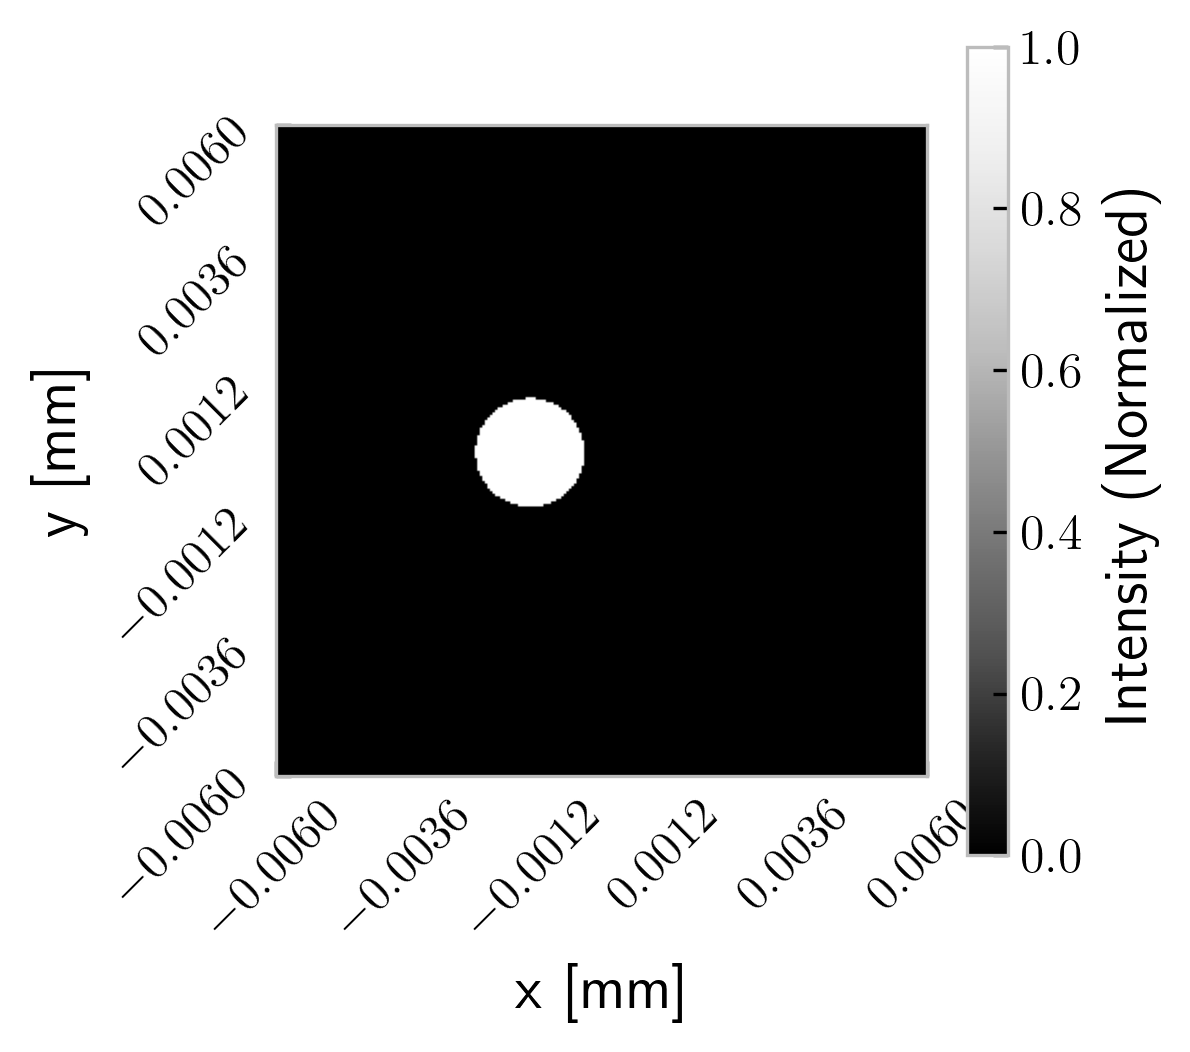

In [235]:
plot_intensity(*bead_img.get_xy(), bead_img.image_mask)

In [236]:
mn_preset = [
    [-2, 2], [0, 2], [2, 2],
    [-3, 3], [-1, 3], [1, 3], [3, 3],
    [-4, 4], [-2, 4], [0, 4], [2, 4], [4, 4],
  #  [-5, 5], [-3, 5], [-1, 5], [1, 5], [3, 5], [5, 5],
  #  [-6, 6], [-4, 6], [-2, 6], [0, 6], [2, 6], [4, 6], [6, 6]
]
rng = np.random.default_rng(seed = 15)
strengths = rng.normal(0, .3, len(mn_preset))
innate_aberration = Aberration(mn_preset, strengths)

In [237]:
slm = SLM(microscope, bead_img, innate_aberration)

Getting unaberrated quality...


In [238]:
corrected_modes = [
    [-2, 2], [0, 2], [2, 2],
    [-3, 3], [-1, 3], [1, 3], [3, 3],
    [-4, 4], [-2, 4], [0, 4], [2, 4], [4, 4]]
correction_log, quality_log, bias_log, final_correction = slm.run_booth(10, corrected_modes)

===== Running Booth 2002 Modal AO Algorithm =====
Noted that only some modes should be corrected.
Original Aberration:
n=-2, m=2: -0.429
n=0, m=2: -0.281
n=2, m=2: 0.118
n=-3, m=3: -0.157
n=-1, m=3: 0.158
n=1, m=3: 0.242
n=3, m=3: -0.433
n=-4, m=4: 0.305
n=-2, m=4: -0.179
n=0, m=4: 0.628
n=2, m=4: 0.219
n=4, m=4: -0.162
===== Iteration 1=====
Getting raw image quality..
Image Quality: 0.272
Applying biases: 0.2 waves
	===Optimizing m=-2, n=2===
	Exploring plus bias...
	Image Quality: 0.217
	Exploring minus bias...
	Image Quality: 0.332
	Evaluating next step...
	Computed step to be: -2150743571.253
		Rounding up to: -0.2 
	===Optimizing m=0, n=2===
	Exploring plus bias...
	Image Quality: 0.241
	Exploring minus bias...
	Image Quality: 0.368
	Evaluating next step...
	Computed step to be: -2361875474.226
		Rounding up to: -0.2 
	===Optimizing m=2, n=2===
	Exploring plus bias...
	Image Quality: 0.353
	Exploring minus bias...
	Image Quality: 0.293
	Evaluating next step...
	Computed step to b

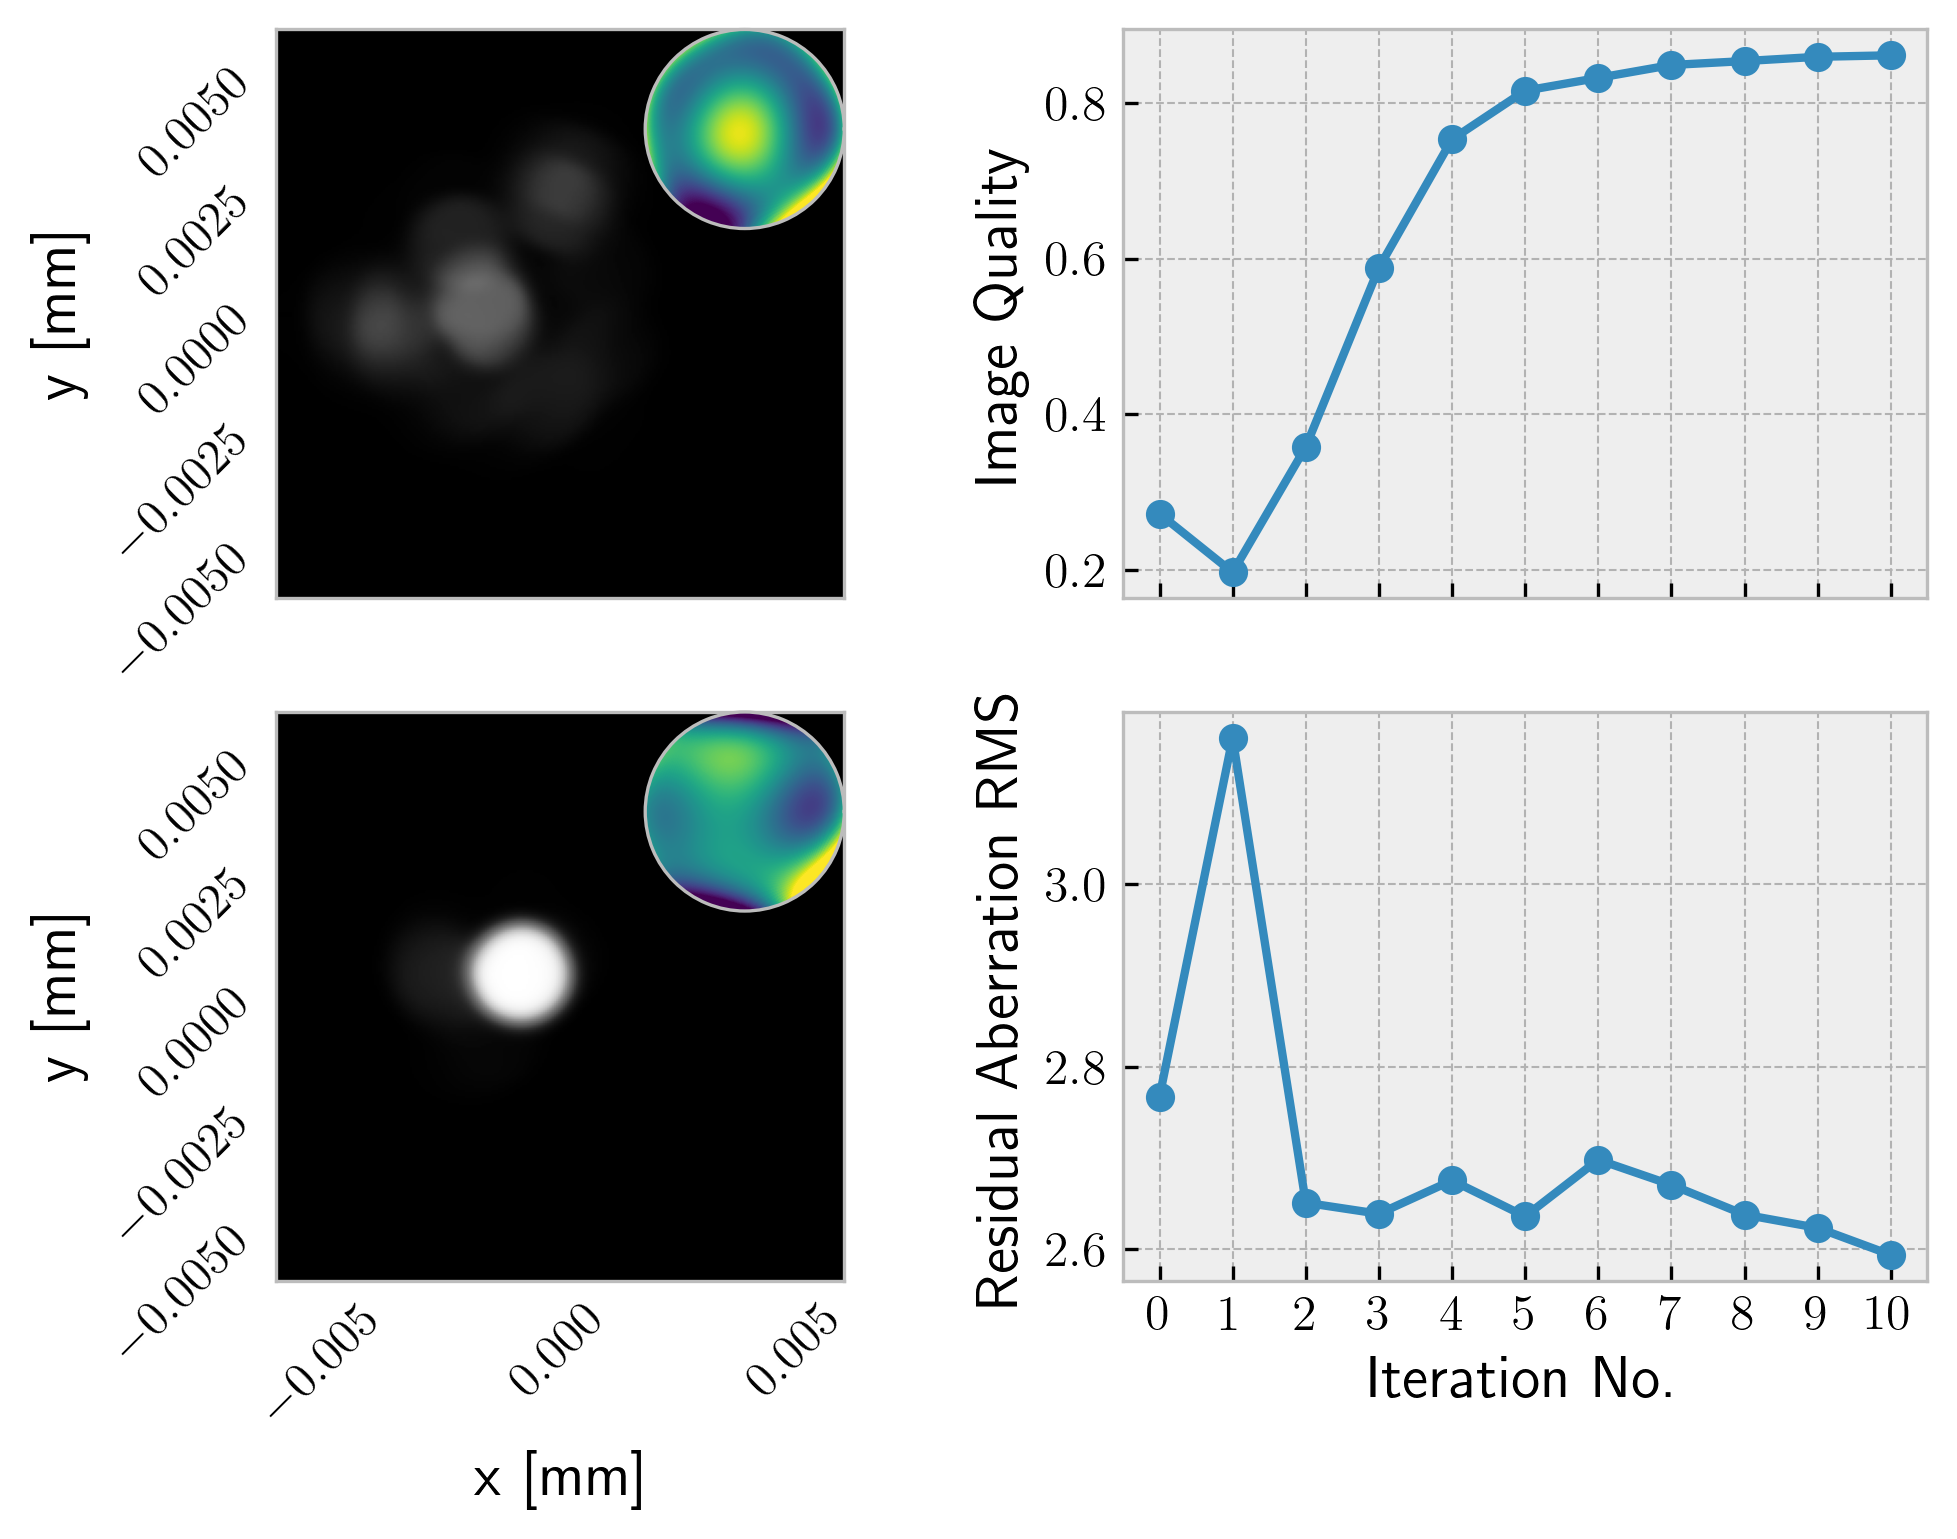

In [239]:
slm.produce_correction_graphic(quality_log, correction_log, final_correction)